# M1_210210 without the emission-line mask

- masked: `results/m1-210210-reference/tau-1/poly10`; lines 3726.0, 3728.8, 4861.3, 4958.9, 5006.8 Å masked $\pm 1500$ km/s.
- unmasked: `no_emission_mask`; `SETTINGS["emission_lines"] = []`, telluric mask kept.
- Same seed 20260832, priors and NSS settings.
- Metallicity is $[\mathrm{Fe}/\mathrm{H}]$ = grid $Z$ + `FEH_OFFSET`.

In [1]:
import os
import re
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")
import corner
import h5py
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path(os.environ.get("CERIDWEN_PROJECT_ROOT", Path.cwd()))
while not (PROJECT_ROOT / "scripts" / "per_galaxy_diagnostics.py").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "scripts"))
import per_galaxy_diagnostics as pgd  # noqa: E402
from build_dr2_quiescent_summary import FEH_OFFSET, formation_times  # noqa: E402
from plot_prior_kl import kl_table  # noqa: E402
from spectral_figures import mark_absorption_features, spectral_tight_layout  # noqa: E402

RESULTS = PROJECT_ROOT / "results/no-emission-mask"
TARGET = "M1_210210"
FIT_DIRS = {"masked": PROJECT_ROOT / "results/m1-210210-reference/tau-1/poly10" / f"210210-{TARGET}",
            "unmasked": RESULTS / "no_emission_mask" / f"210210-{TARGET}"}
COLOURS = {"masked": "k", "unmasked": "tab:red"}
NAMES = {"masked": "emission lines masked", "unmasked": "no emission-line mask"}
REF = "masked"
LABELS = {"logmass": r"$\log_{10}(M_\star/M_\odot)$", "Z": r"$[\mathrm{Fe}/\mathrm{H}]$", "afe": r"$[\alpha/\mathrm{Fe}]$",
          "tau_dust": r"$\tau_{\mathrm{dust}}$", "dust_index": r"$\delta_{\rm dust}$", "age": r"$t_{\mathrm{MW}}$ [Gyr]"}
pd.set_option("display.width", 250); pd.set_option("display.max_columns", 60); pd.set_option("display.precision", 3)

## Evidence and $\chi^2$

- `spec_chi2_raw`: catalogue uncertainties only, posterior-median model, each arm's own pixels.
- `spec_chi2_raw_common`: the same over pixels fitted in both arms.
- `spec_chi2_fref`: at the masked arm's calibration floor.
- Stored $\chi^2$ uses each fit's own floor.

In [2]:
def _text(v):
    return v.decode() if isinstance(v, bytes) else str(v)


def load_fit(folder):
    out = {"folder": folder}
    with h5py.File(folder / "ceridwen_derived_outputs.h5", "r") as d:
        out["attrs"] = dict(d.attrs)
        names = [_text(v) for v in d["summary/parameter"][:]]
        out["summary"] = pd.DataFrame({"q16": d["summary/q16"][:], "q50": d["summary/q50"][:], "q84": d["summary/q84"][:]}, index=names)
        out["diag"] = dict(d["diagnostics"].attrs)
        for grp in ("spectrum", "photometry", "sfh", "calibration"):
            out[grp] = {k: d[grp][k][:] for k in d[grp]}
        out["calibration"]["attrs"] = dict(d["calibration"].attrs)
    with h5py.File(folder / "ceridwen_result.h5", "r") as r:
        out["tau_max"] = float(re.search(r"diffuse_tau_kc: .*?Uniform\(0, ([0-9.]+)\)", _text(r["model"].attrs["parameter_block"])).group(1))
        out["n_calls"] = int(r["samples"].attrs["n_likelihood_calls"])
        out["wall_s"] = float(r["samples"].attrs["wall_time_s"])
    out["galaxy"] = pgd.load_galaxy(folder)
    return out


fits = {k: load_fit(v) for k, v in FIT_DIRS.items()}
REF_FLOOR = fits[REF]["summary"].loc["calibration floor [%]", "q50"]


COMMON = fits[REF]["spectrum"]["mask"].astype(bool)  # pixels fitted in both arms


def chi2_at_floor(fit, f_pct, mask=None):
    spec = fit["spectrum"]; mask = spec["mask"].astype(bool) if mask is None else mask
    sigma = np.hypot(spec["uncertainty"], (f_pct / 100.0) * np.abs(spec["posterior_q50"]))
    return float(np.sum(((spec["observed"] - spec["posterior_q50"]) / sigma)[mask] ** 2))


def summary_row(fit):
    s, d = fit["summary"], fit["diag"]
    g = fit["galaxy"]; w = pgd.posterior_weights(g)
    t20, t50, t80 = formation_times(fit["sfh"]["lookback_time_gyr"], fit["sfh"]["mass_fraction_draws"])
    row = dict(order=int(fit["calibration"]["attrs"]["order"]), tau_max=fit["tau_max"], seed=g.seed, lnZ=float(d["log_evidence"]), lnZ_err=float(d["log_evidence_err"]),
               n_pix=int(fit["spectrum"]["mask"].sum()), spec_chi2_raw=chi2_at_floor(fit, 0.0), spec_chi2_fref=chi2_at_floor(fit, REF_FLOOR), spec_chi2_raw_common=chi2_at_floor(fit, 0.0, COMMON),
               spec_chi2_stored=float(d["spectrum_chi2"]), phot_chi2=float(d["photometry_chi2"]), phot_n=int(d["photometry_ndof"]),
               ess=float(d["posterior_weight_ess"]), passed=bool(d["passed"]), calls=fit["n_calls"], wall_s=fit["wall_s"])
    for name, key in [("logmass", "logmass"), ("Z", "Z"), ("afe", "afe"), ("tau_dust", "diffuse_tau_kc"),
                      ("age", "mass-weighted age [Gyr]"), ("f_calib", "calibration floor [%]")]:
        row[f"{name}_q50"], row[f"{name}_hw"] = s.loc[key, "q50"], 0.5 * (s.loc[key, "q84"] - s.loc[key, "q16"])
    row["feh_q50"], row["feh_hw"] = row.pop("Z_q50") + FEH_OFFSET, row.pop("Z_hw")
    q16, q50, q84 = (pgd.weighted_quantile(np.ravel(g.samples["diffuse_dust_index"]), w, q) for q in (0.16, 0.5, 0.84))
    row["dust_index_q50"], row["dust_index_hw"] = q50, 0.5 * (q84 - q16)
    for name, t in [("t20", t20), ("t50", t50), ("t80", t80)]:
        q16, q50, q84 = np.percentile(t, [16, 50, 84])
        row[f"{name}_q50"], row[f"{name}_hw"] = q50, 0.5 * (q84 - q16)
    for key in ("zred", "sigma_smooth"):
        if key in s.index:
            row[f"{key}_q50"], row[f"{key}_hw"] = s.loc[key, "q50"], 0.5 * (s.loc[key, "q84"] - s.loc[key, "q16"])
    return row


table = pd.DataFrame({k: summary_row(v) for k, v in fits.items()}).T
table.to_csv(RESULTS / "comparison.csv")
display(table.T)

,masked,unmasked
order,10,10
tau_max,1.0,1.0
seed,20260832,20260832
lnZ,231153.155,258237.779
lnZ_err,0.349,0.452
n_pix,3523,3939
spec_chi2_raw,10772.142,12368.35
spec_chi2_fref,3654.973,4072.813
spec_chi2_raw_common,10772.142,10955.514
spec_chi2_stored,3649.151,4034.391


## Shift, width and KL per parameter

- Shift: unmasked median minus masked median, in masked half-widths.
- Half-width: half the 16-84% interval.
- Bits: $D_{\mathrm{KL}}$ from each fit's own prior, `kl_table`.
- Mass-weighted age is derived; it has no prior and no bits.

In [3]:
def posterior_table(g):
    w = pgd.posterior_weights(g)
    rows = {}
    for name in g.prior_text:
        x = np.asarray(g.samples[name], dtype=float).reshape(len(w), -1)
        for j in range(x.shape[1]):
            q16, q50, q84 = (pgd.weighted_quantile(x[:, j], w, q) for q in (0.16, 0.5, 0.84))
            rows[name if x.shape[1] == 1 else f"{name}[{j}]"] = dict(q50=q50, hw=0.5 * (q84 - q16))
    q16, q50, q84 = np.percentile(g.mass_weighted_age_draws, [16, 50, 84])
    rows["mass_weighted_age_gyr"] = dict(q50=q50, hw=0.5 * (q84 - q16))
    out = pd.DataFrame(rows).T
    kl = kl_table(g)
    out["bits"], out["bits_err"], out["label"] = kl["bits"], kl["err"], kl["label"]
    out.loc["mass_weighted_age_gyr", "label"] = LABELS["age"]
    return out


a, b = (posterior_table(fits[k]["galaxy"]) for k in ("masked", "unmasked"))
shifts = pd.DataFrame({"label": a["label"], "masked_q50": a["q50"], "unmasked_q50": b["q50"], "masked_hw": a["hw"], "unmasked_hw": b["hw"],
                       "shift_in_masked_hw": (b["q50"] - a["q50"]) / a["hw"], "width_ratio": b["hw"] / a["hw"],
                       "masked_bits": a["bits"], "masked_bits_err": a["bits_err"], "unmasked_bits": b["bits"], "unmasked_bits_err": b["bits_err"]})
shifts.to_csv(RESULTS / "parameter-shifts.csv")
display(shifts.drop(columns="label"))

,masked_q50,unmasked_q50,masked_hw,unmasked_hw,shift_in_masked_hw,width_ratio,masked_bits,masked_bits_err,unmasked_bits,unmasked_bits_err
Z,-1.894,-1.887,2.114e-02,1.942e-02,0.338,0.919,5.107,0.011,5.197,0.016
afe,0.061,0.044,9.638e-03,9.739e-03,-1.720,1.010,4.327,0.012,4.315,0.014
diffuse_dust_index,-0.987,-0.987,1.353e-02,1.491e-02,0.013,1.102,4.981,0.015,4.823,0.018
diffuse_tau_kc,0.406,0.397,1.318e-02,1.461e-02,-0.650,1.108,4.168,0.013,4.054,0.013
log_f_calib,-3.678,-3.672,1.820e-02,1.752e-02,0.290,0.963,4.922,0.014,4.998,0.014
logmass,11.650,11.645,1.229e-02,1.152e-02,-0.366,0.937,6.613,0.013,6.693,0.015
logsfr_ratios[0],2.307,2.369,5.630e-01,6.641e-01,0.111,1.180,5.839,0.020,5.695,0.024
logsfr_ratios[1],0.142,0.110,3.416e-01,3.644e-01,-0.093,1.067,0.201,0.008,0.131,0.008
logsfr_ratios[2],0.023,0.008,3.093e-01,3.037e-01,-0.049,0.982,0.091,0.005,0.095,0.005
logsfr_ratios[3],-0.092,-0.108,3.316e-01,3.449e-01,-0.048,1.040,0.142,0.006,0.132,0.007


## Fit and SFH

- Top: spectrum medians. Middle: calibration polynomial median, 16-84 band. Bottom: photometry.
- SFH median with 16-84 band.

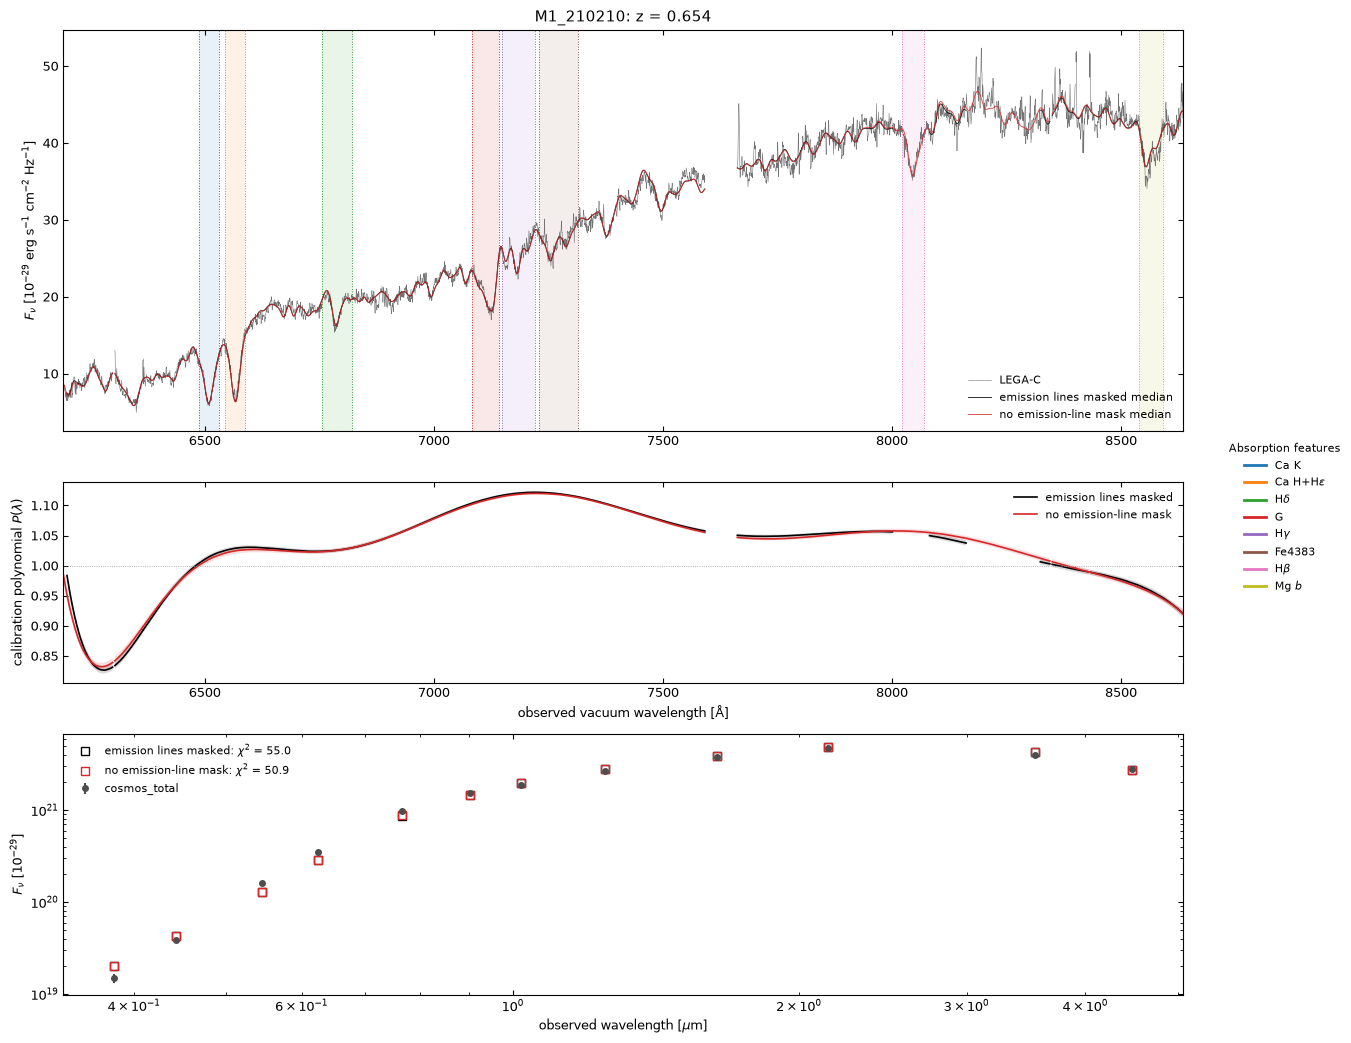

In [4]:
ref = fits[REF]; s = ref["spectrum"]; wave = s["wavelength"]; rmask = s["mask"].astype(bool)
fig, axes = plt.subplots(3, 1, figsize=(12, 10.5), gridspec_kw={"height_ratios": [2, 1, 1.3]})
scale = 1e29
wide = fits["unmasked"]["spectrum"]["mask"].astype(bool)
axes[0].plot(wave, np.where(wide, s["observed"] * scale, np.nan), color="0.45", lw=0.4, label="LEGA-C")
p = ref["photometry"]; pm = p["mask"].astype(bool); lam = p["wavelength"] / 1e4
axes[2].errorbar(lam[pm], p["observed"][pm] * scale, yerr=p["uncertainty"][pm] * scale, fmt="o", color="0.3", ms=4, label="cosmos_total")
for k, fit in fits.items():
    rmask = fit["spectrum"]["mask"].astype(bool)
    axes[0].plot(wave, np.where(rmask, fit["spectrum"]["posterior_q50"] * scale, np.nan), color=COLOURS[k], lw=0.7, alpha=0.8, label=f"{NAMES[k]} median")
    cal = {q: np.where(rmask, fit["calibration"][q], np.nan) for q in ("polynomial_q16", "polynomial_q50", "polynomial_q84")}
    axes[1].plot(wave, cal["polynomial_q50"], color=COLOURS[k], lw=1.2, label=NAMES[k])
    axes[1].fill_between(wave, cal["polynomial_q16"], cal["polynomial_q84"], color=COLOURS[k], alpha=0.15, lw=0)
    q = fit["photometry"]
    axes[2].plot(lam[pm], q["posterior_q50"][pm] * scale, "s", mfc="none", color=COLOURS[k], ms=6, label=rf"{NAMES[k]}: $\chi^2$ = {np.sum(q['pull'][pm] ** 2):.1f}")
for ax in axes[:2]:
    ax.set_xlim(wave[wide].min(), wave[wide].max())
axes[0].set_ylabel(r"$F_\nu$ [$10^{-29}$ erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]")
axes[0].set_title(f"{TARGET}: z = {ref['attrs']['redshift']:.3f}")
axes[0].legend(frameon=False, fontsize=8, loc="lower right")
axes[1].axhline(1.0, color="0.6", lw=0.6, ls=":")
axes[1].set(xlabel=r"observed vacuum wavelength [$\mathrm{\AA}$]", ylabel=r"calibration polynomial $P(\lambda)$")
axes[1].legend(frameon=False, fontsize=8, loc="upper right")
axes[2].set(xscale="log", yscale="log", xlabel=r"observed wavelength [$\mu$m]", ylabel=r"$F_\nu$ [$10^{-29}$]")
axes[2].legend(frameon=False, fontsize=8)
mark_absorption_features(axes[0], ref["attrs"]["redshift"], xlabel="")
spectral_tight_layout(fig)
fig.savefig(RESULTS / f"fit-{TARGET}.png", dpi=130); plt.show()

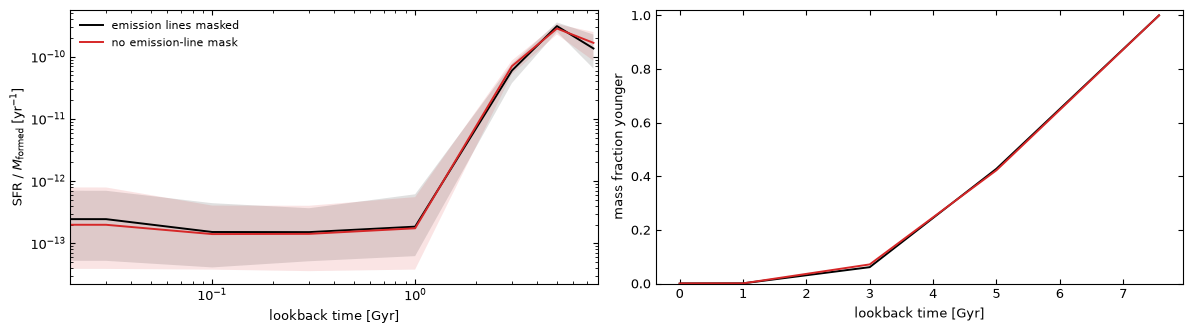

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.4))
for k, fit in fits.items():
    sfh = fit["sfh"]; lb = sfh["lookback_time_gyr"]
    axes[0].plot(lb, sfh["normalized_sfr_q50"], color=COLOURS[k], lw=1.4, label=NAMES[k])
    axes[0].fill_between(lb, sfh["normalized_sfr_q16"], sfh["normalized_sfr_q84"], color=COLOURS[k], alpha=0.12, lw=0)
    younger = np.concatenate([[0.0], np.cumsum(sfh["mass_fraction_q50"])])
    axes[1].plot(lb, younger / younger[-1], color=COLOURS[k], lw=1.4, label=NAMES[k])
axes[0].set(xscale="log", yscale="log", xlabel="lookback time [Gyr]", ylabel=r"SFR / $M_{\rm formed}$ [yr$^{-1}$]", xlim=(0.02, lb[-1] * 1.05))
axes[1].set(xlabel="lookback time [Gyr]", ylabel="mass fraction younger", ylim=(0, 1.02))
axes[0].legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(RESULTS / f"sfh-{TARGET}.png", dpi=130); plt.show()

## Residual pull at the formerly masked lines

- No-mask fit only; pull = (observed - posterior-median model) / $\sqrt{\sigma^2 + (f_{\rm calib}\,\mathrm{model})^2}$.
- Windows of $\pm 1500$ and $\pm 300$ km/s about each rest wavelength at the catalogue $z$.
- `mean_pull_err` is $1/\sqrt{N}$, for independent unit-variance pixels.

In [6]:
LINES = {"[O II] 3726": 3726.0, "[O II] 3729": 3728.8, "H-beta": 4861.3, "[O III] 4959": 4958.9, "[O III] 5007": 5006.8}
fit = fits["unmasked"]; s = fit["spectrum"]; fitted = s["mask"].astype(bool); z = float(fit["attrs"]["redshift"])
floor = fit["summary"].loc["calibration floor [%]", "q50"] / 100.0
pull = (s["observed"] - s["posterior_q50"]) / np.hypot(s["uncertainty"], floor * np.abs(s["posterior_q50"]))
rows = []
for name, rest in LINES.items():
    for dv in (1500.0, 300.0):
        k = fitted & (np.abs(s["wavelength"] / (rest * (1 + z)) - 1) <= dv / 2.998e5)
        rows.append({"line": name, "half_width_kms": dv, "n_pix": int(k.sum()), "mean_pull": pull[k].mean() if k.any() else np.nan,
                     "mean_pull_err": 1 / np.sqrt(k.sum()) if k.any() else np.nan, "rms_pull": pull[k].std() if k.any() else np.nan})
line_pulls = pd.DataFrame(rows)
line_pulls.to_csv(RESULTS / "line-residual-pulls.csv", index=False)
print(f"all fitted pixels: N = {fitted.sum()}, mean pull {pull[fitted].mean():+.3f}, rms {pull[fitted].std():.3f}")
display(line_pulls)

all fitted pixels: N = 3939, mean pull +0.021, rms 1.011


,line,half_width_kms,n_pix,mean_pull,mean_pull_err,rms_pull
0,[O II] 3726,1500.0,5,-1.830,0.447,0.681
1,[O II] 3726,300.0,0,NaN,NaN,NaN
2,[O II] 3729,1500.0,13,-1.400,0.277,1.111
3,[O II] 3729,300.0,0,NaN,NaN,NaN
4,H-beta,1500.0,134,0.046,0.086,0.532
5,H-beta,300.0,27,0.095,0.192,0.527
6,[O III] 4959,1500.0,137,0.297,0.085,1.260
7,[O III] 4959,300.0,27,0.851,0.192,1.183
8,[O III] 5007,1500.0,138,0.079,0.085,0.718
9,[O III] 5007,300.0,28,0.573,0.189,0.677


## Posteriors, masked against no mask

- Grey shapes are the fit with emission lines masked and red outlines the fit with no mask, each the $1\sigma$ contour with the 1D posteriors on the diagonal: an offset between a red outline and its grey shape means those parameters moved, and a smaller red outline means a tighter constraint.

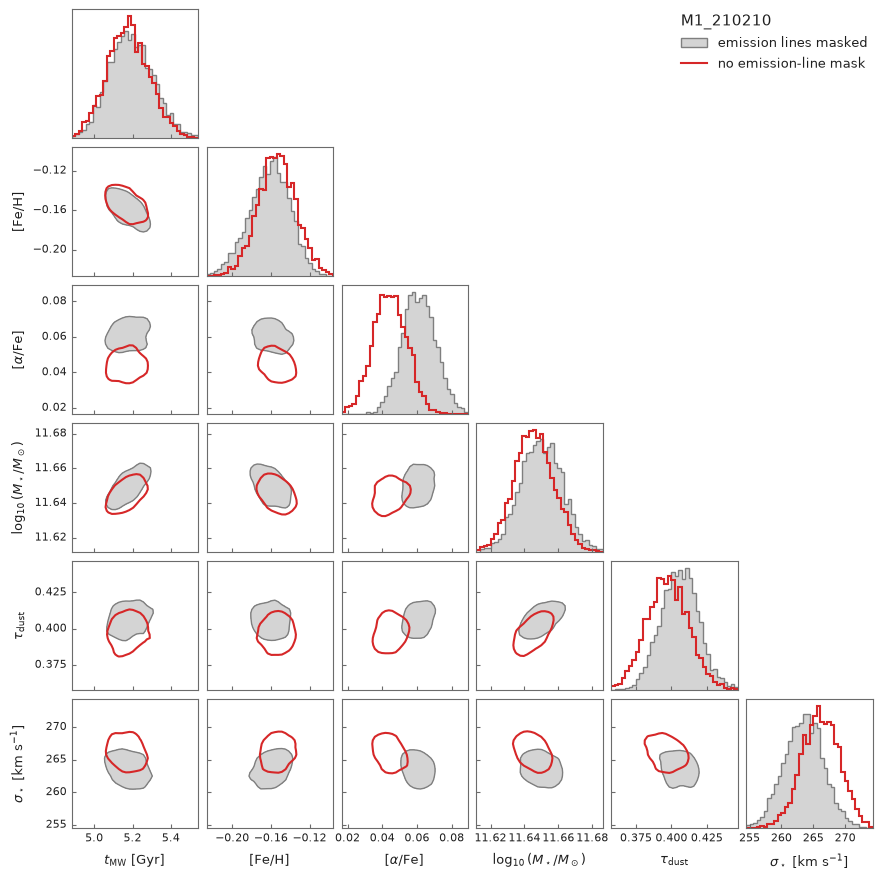

In [7]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MaxNLocator

CORNER_LABELS = [r"$t_\mathrm{MW}$ [Gyr]", r"$[\mathrm{Fe/H}]$", r"$[\alpha/\mathrm{Fe}]$", r"$\log_{10}(M_\star/M_\odot)$",
                 r"$\tau_\mathrm{dust}$", r"$\sigma_\star$ [km s$^{-1}$]"]
GREY_FILL, GREY_LINE, RED = "#D4D4D4", "#7F7F7F", "tab:red"


def mw_age_samples(g):
    r = np.asarray(g.samples["logsfr_ratios"])
    h = 10.0 ** np.concatenate([np.zeros((len(r), 1)), -np.cumsum(r, axis=1)], axis=1)
    edges = g.sfh_edges_gyr
    m = 0.5 * (h[:, :-1] + h[:, 1:]) * np.diff(edges)
    return (m * (0.5 * (edges[:-1] + edges[1:]))).sum(1) / m.sum(1)


def corner_data(g):
    return np.column_stack([mw_age_samples(g), g.samples["Z"] + FEH_OFFSET, g.samples["afe"], g.samples["logmass"],
                            g.samples["diffuse_tau_kc"], g.samples["sigma_smooth"]])


data = {k: (corner_data(f["galaxy"]), pgd.posterior_weights(f["galaxy"])) for k, f in fits.items()}
n = len(CORNER_LABELS)
rng_ = [(min(pgd.weighted_quantile(x[:, i], w, 0.002) for x, w in data.values()),
         max(pgd.weighted_quantile(x[:, i], w, 0.998) for x, w in data.values())) for i in range(n)]
style = {"axes.edgecolor": "#6B6B6B", "xtick.color": "#6B6B6B", "ytick.color": "#6B6B6B", "xtick.labelcolor": "#1F1F1F",
         "ytick.labelcolor": "#1F1F1F", "axes.labelcolor": "#1F1F1F", "text.color": "#1F1F1F"}
with plt.rc_context(style):
    fig = plt.figure(figsize=(9, 9))
    common = dict(labels=CORNER_LABELS, range=rng_, bins=36, smooth=1.2, plot_datapoints=False, plot_density=False,
                  levels=[1 - np.exp(-0.5)], hist_kwargs=dict(lw=0), fig=fig)  # 1-sigma contour in two dimensions
    corner.corner(data["masked"][0], weights=data["masked"][1], color=GREY_LINE, fill_contours=True,
                  contourf_kwargs=dict(colors=["white", GREY_FILL]), contour_kwargs=dict(linewidths=1.0, colors=GREY_LINE), **common)
    corner.corner(data["unmasked"][0], weights=data["unmasked"][1], color=RED, no_fill_contours=True,
                  contour_kwargs=dict(linewidths=1.5, colors=RED), **common)
    grid = np.array(fig.axes).reshape(n, n)
    for (i, j), ax in np.ndenumerate(grid):
        if j > i:
            continue
        if i == j:  # diagonal: weighted, density-normalised, shared bins; masked filled, no mask as a line
            for artist in list(ax.patches) + list(ax.lines):
                artist.remove()
            edges = np.linspace(*rng_[i], 37)
            dens = {k: np.histogram(x[:, i], bins=edges, weights=w, density=True)[0] for k, (x, w) in data.items()}
            ax.stairs(dens["masked"], edges, fill=True, color=GREY_FILL, lw=0)
            ax.stairs(dens["masked"], edges, color=GREY_LINE, lw=1.0)
            ax.stairs(dens["unmasked"], edges, color=RED, lw=1.5)
            ax.set_ylim(0, 1.06 * max(d.max() for d in dens.values()))
            ax.set_yticks([])
        else:
            ax.yaxis.set_major_locator(MaxNLocator(4, prune="both"))
        ax.xaxis.set_major_locator(MaxNLocator(4, prune="both"))
        ax.tick_params(labelsize=8, length=3, top=False, right=False, labelrotation=0, labelbottom=i == n - 1, labelleft=j == 0 and i > 0)
        plt.setp(ax.get_xticklabels(), ha="center")
        plt.setp(ax.get_yticklabels(), va="center")
        ax.xaxis.label.set_size(9.5)
        ax.yaxis.label.set_size(9.5)
        ax.xaxis.set_label_coords(0.5, -0.2)
        ax.yaxis.set_label_coords(-0.36, 0.5)
    fig.subplots_adjust(left=0.095, right=0.985, bottom=0.075, top=0.985, wspace=0.07, hspace=0.07)
    fig.legend(handles=[Patch(facecolor=GREY_FILL, edgecolor=GREY_LINE, lw=1.0, label=NAMES["masked"]),
                        Line2D([], [], color=RED, lw=1.5, label=NAMES["unmasked"])],
               title=TARGET, title_fontsize=10.5, alignment="left", loc="upper right", bbox_to_anchor=(0.985, 0.985),
               frameon=False, fontsize=9.5, borderaxespad=0, labelspacing=0.5)
    fig.savefig(RESULTS / f"corner-{TARGET}.png", dpi=200, facecolor="white"); plt.show()
